# Financial Time-Series Forecasting and Scenario Analysis
## NVIDIA Stock 1999 to 2026 — Predicting 5-Day Forward Returns

NVIDIA went public in January 1999 at a split-adjusted price of roughly three cents. By October 2025 it had reached an all-time high of $20.73, a total return of over 59,000 percent across 27 years and five distinct business eras. That trajectory is not just a stock story. It is a record of how a graphics chip company became the primary infrastructure layer of modern artificial intelligence.

This notebook builds a complete machine learning forecasting pipeline on 7,079 trading days of that record. The target variable is the 5-day forward return: given today's conditions, what percentage gain or loss will the stock produce over the next five trading days? This is a more practically useful question than predicting a raw price level, because returns are stationary, comparable across time, and directly actionable in a portfolio context.

The workflow covers ten analytical stages: data exploration, time-series decomposition, feature engineering, a classical ARIMA baseline, gradient boosting forecasting, time-series cross-validation, evaluation, feature importance, anomaly detection, and scenario simulation under two macroeconomic stress cases.

Dataset: NVIDIA Stock Data 1999 to 2026, covering 7,079 trading days across 16 columns including OHLCV prices, moving averages, RSI, quarterly revenue, market cap, stock split dates, and era labels.


## 1. Setup


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#0a0a0f',
    'axes.facecolor':    '#111118',
    'axes.edgecolor':    '#2a2a3a',
    'axes.labelcolor':   '#ccccdd',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.color':       '#777788',
    'ytick.color':       '#777788',
    'text.color':        '#ccccdd',
    'grid.color':        '#1a1a28',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.titlecolor':   '#ffffff',
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'legend.facecolor':  '#1a1a28',
    'legend.edgecolor':  '#333348',
})

NV_GREEN = '#76b900'
NV_WHITE = '#ffffff'
GOLD     = '#fbbf24'
RED      = '#ef4444'
BLUE     = '#60a5fa'
PURPLE   = '#a78bfa'
TEAL     = '#2dd4bf'

ERA_COLORS = {
    'Pre-GPU Era':        '#555577',
    'Gaming GPU Era':     NV_GREEN,
    'Deep Learning Era':  BLUE,
    'Data Center Growth': GOLD,
    'Generative AI Era':  RED,
}

print("Ready")


Ready


## 2. Data Exploration

The dataset covers 7,079 trading days from January 1999 through March 2026. Prices are split-adjusted throughout — NVIDIA went through six stock splits, including a 10-for-1 split in June 2024. The dataset organises history into five eras that correspond to how the company's primary business evolved.

Before building any predictive model it pays to understand the raw structure: how prices evolved, how returns are distributed, how volatility changed across eras, and how fundamental measures like revenue and market cap relate to price.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/alitaqishah/nvidia-stock-data-19992026-the-ai-mega-stock/nvidia_stock_data_1999_2026.csv')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)
df['daily_return'] = df['close'].pct_change()

print(f"Shape:        {df.shape}")
print(f"Date range:   {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Trading days: {len(df):,}")
print()
print("Eras and trading days per era:")
print(df['era'].value_counts().sort_values(ascending=False).to_string())
print()
print(f"IPO close (Jan 1999):      ${df['close'].iloc[0]:.4f}")
print(f"All-time high:             ${df['close'].max():.4f}  on {df.loc[df['close'].idxmax(),'date'].date()}")
print(f"Latest close (Mar 2026):   ${df['close'].iloc[-1]:.2f}")
print(f"Total return (split-adj):  {(df['close'].iloc[-1]/df['close'].iloc[0]-1)*100:,.0f}%")


Shape:        (7079, 17)
Date range:   1999-01-22 to 2026-03-11
Trading days: 7,079

Eras and trading days per era:
era
Gaming GPU Era        1826
Deep Learning Era     1826
Pre-GPU Era           1811
Generative AI Era      833
Data Center Growth     783

IPO close (Jan 1999):      $0.0313
All-time high:             $20.7284  on 2025-10-30
Latest close (Mar 2026):   $18.60
Total return (split-adj):  59,325%


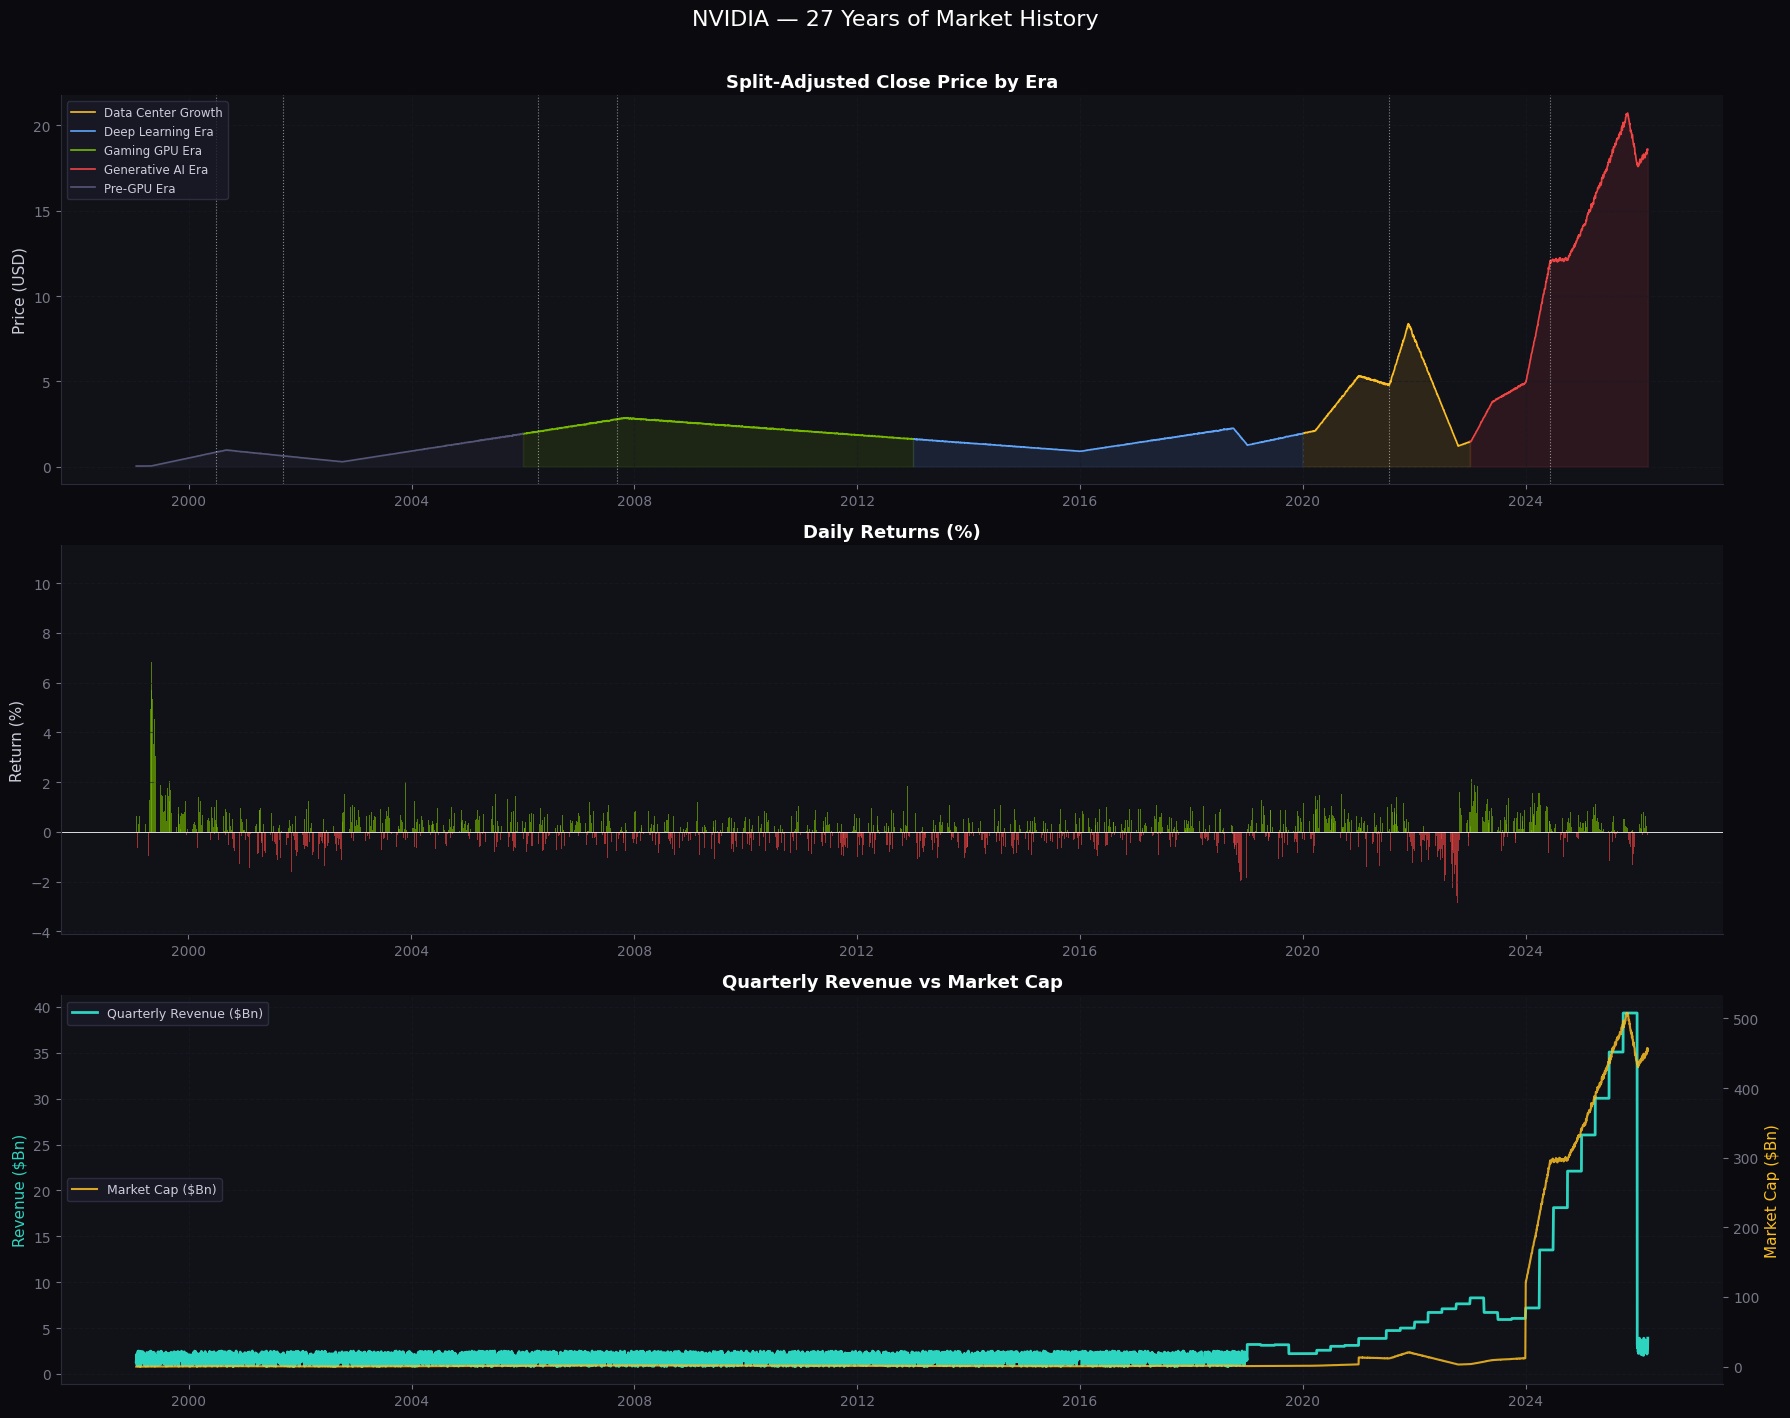

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('NVIDIA — 27 Years of Market History', fontsize=16, color='white', y=1.01)

# Price by era
ax = axes[0]
for era, grp in df.groupby('era'):
    ax.fill_between(grp['date'], grp['close'], alpha=0.12, color=ERA_COLORS[era])
    ax.plot(grp['date'], grp['close'], color=ERA_COLORS[era], linewidth=1.2, label=era)
for _, row in df[df['stock_split'].notna()].iterrows():
    ax.axvline(row['date'], color='white', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_title('Split-Adjusted Close Price by Era')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(True)

# Daily returns
ax = axes[1]
ax.bar(df['date'], df['daily_return'] * 100,
       color=[NV_GREEN if r >= 0 else RED for r in df['daily_return'].fillna(0)],
       alpha=0.65, width=1.2)
ax.axhline(0, color='white', linewidth=0.6)
ax.set_title('Daily Returns (%)')
ax.set_ylabel('Return (%)')
ax.grid(True, axis='y')

# Revenue vs market cap
ax = axes[2]
ax2 = ax.twinx()
ax.plot(df['date'], df['quarterly_revenue_usd_bn'],
        color=TEAL, linewidth=2, label='Quarterly Revenue ($Bn)')
ax2.plot(df['date'], df['market_cap_usd_bn'],
         color=GOLD, linewidth=1.5, alpha=0.85, label='Market Cap ($Bn)')
ax.set_title('Quarterly Revenue vs Market Cap')
ax.set_ylabel('Revenue ($Bn)', color=TEAL)
ax2.set_ylabel('Market Cap ($Bn)', color=GOLD)
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='center left', fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('price_history.png', dpi=150, bbox_inches='tight')
plt.show()


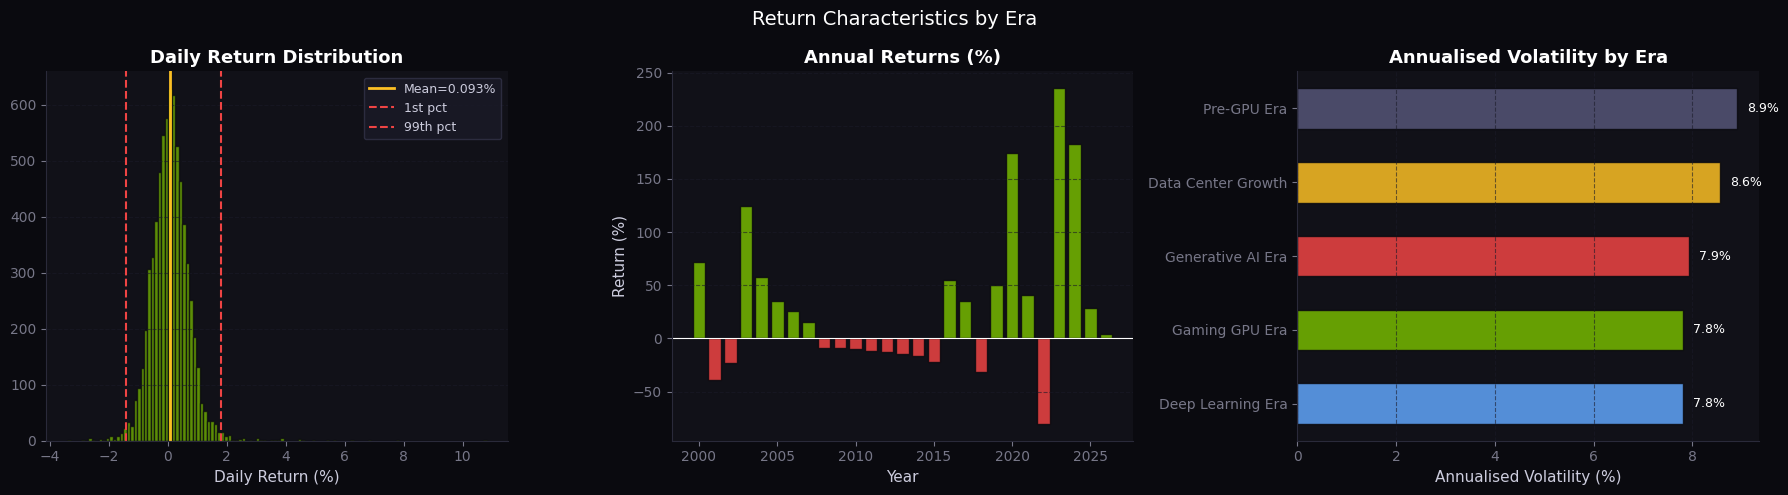

Daily return summary:
  Mean:      0.0925%
  Std:       0.6708%
  Worst day: -3.41%
  Best day:  10.81%
  Skewness:  1.676
  Kurtosis:  18.393


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Return Characteristics by Era', fontsize=14, color='white')

# Return distribution
ax = axes[0]
ret = df['daily_return'].dropna()
ax.hist(ret * 100, bins=120, color=NV_GREEN, alpha=0.75, edgecolor='#0a0a0f')
ax.axvline(ret.mean()*100, color=GOLD, linewidth=2, label=f'Mean={ret.mean()*100:.3f}%')
ax.axvline(ret.quantile(0.01)*100, color=RED, linewidth=1.5, linestyle='--', label='1st pct')
ax.axvline(ret.quantile(0.99)*100, color=RED, linewidth=1.5, linestyle='--', label='99th pct')
ax.set_title('Daily Return Distribution')
ax.set_xlabel('Daily Return (%)')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# Annual returns
df['year'] = df['date'].dt.year
ann = df.groupby('year')['close'].last().pct_change().dropna()
ax = axes[1]
ax.bar(ann.index, ann.values*100,
       color=[NV_GREEN if v>0 else RED for v in ann.values],
       alpha=0.85, edgecolor='#0a0a0f')
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('Annual Returns (%)')
ax.set_xlabel('Year')
ax.set_ylabel('Return (%)')
ax.grid(True, axis='y')

# Volatility by era
df['vol_30d'] = df['daily_return'].rolling(30).std() * np.sqrt(252)
era_vol = df.groupby('era')['vol_30d'].mean().sort_values()
ax = axes[2]
bars = ax.barh(era_vol.index, era_vol.values*100,
               color=[ERA_COLORS[e] for e in era_vol.index],
               alpha=0.85, edgecolor='#0a0a0f', height=0.55)
for bar, v in zip(bars, era_vol.values):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{v*100:.1f}%', va='center', fontsize=9, color='white')
ax.set_title('Annualised Volatility by Era')
ax.set_xlabel('Annualised Volatility (%)')
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig('return_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Daily return summary:")
print(f"  Mean:      {ret.mean()*100:.4f}%")
print(f"  Std:       {ret.std()*100:.4f}%")
print(f"  Worst day: {ret.min()*100:.2f}%")
print(f"  Best day:  {ret.max()*100:.2f}%")
print(f"  Skewness:  {ret.skew():.3f}")
print(f"  Kurtosis:  {ret.kurtosis():.3f}")


## 3. Time-Series Decomposition

Time-series data can be broken into a trend component, a seasonal component, and residual noise. Decomposing the series is not just a visualisation exercise — it tells us what kind of structure we are dealing with before choosing models and features.

We first run the Augmented Dickey-Fuller test to check stationarity. Raw price levels are almost always non-stationary. Returns are typically stationary, which matters because our target variable is a 5-day return rather than a price level. A stationary target means we do not need to difference or transform it before modelling.

We then decompose the close price using a multiplicative model over the final four years of training data, where multiplicative is appropriate because the fluctuation amplitude scales with the price level.


In [5]:
adf_price = adfuller(df['close'].dropna())
adf_ret   = adfuller(df['daily_return'].dropna())

print("Augmented Dickey-Fuller Test — Stationarity Check")
print()
print(f"  Close price")
print(f"    ADF stat:  {adf_price[0]:.3f}")
print(f"    p-value:   {adf_price[1]:.4f}")
print(f"    Result:    {'NON-STATIONARY — trend present' if adf_price[1]>0.05 else 'Stationary'}")
print()
print(f"  Daily returns")
print(f"    ADF stat:  {adf_ret[0]:.3f}")
print(f"    p-value:   {adf_ret[1]:.4f}")
print(f"    Result:    {'Stationary' if adf_ret[1]<0.05 else 'NON-STATIONARY'}")
print()
print("Because our target is a 5-day forward return (not a price level), we are")
print("forecasting a stationary series. This is an advantage: the model does not")
print("need to track an ever-growing price scale.")


Augmented Dickey-Fuller Test — Stationarity Check

  Close price
    ADF stat:  1.126
    p-value:   0.9954
    Result:    NON-STATIONARY — trend present

  Daily returns
    ADF stat:  -6.722
    p-value:   0.0000
    Result:    Stationary

Because our target is a 5-day forward return (not a price level), we are
forecasting a stationary series. This is an advantage: the model does not
need to track an ever-growing price scale.


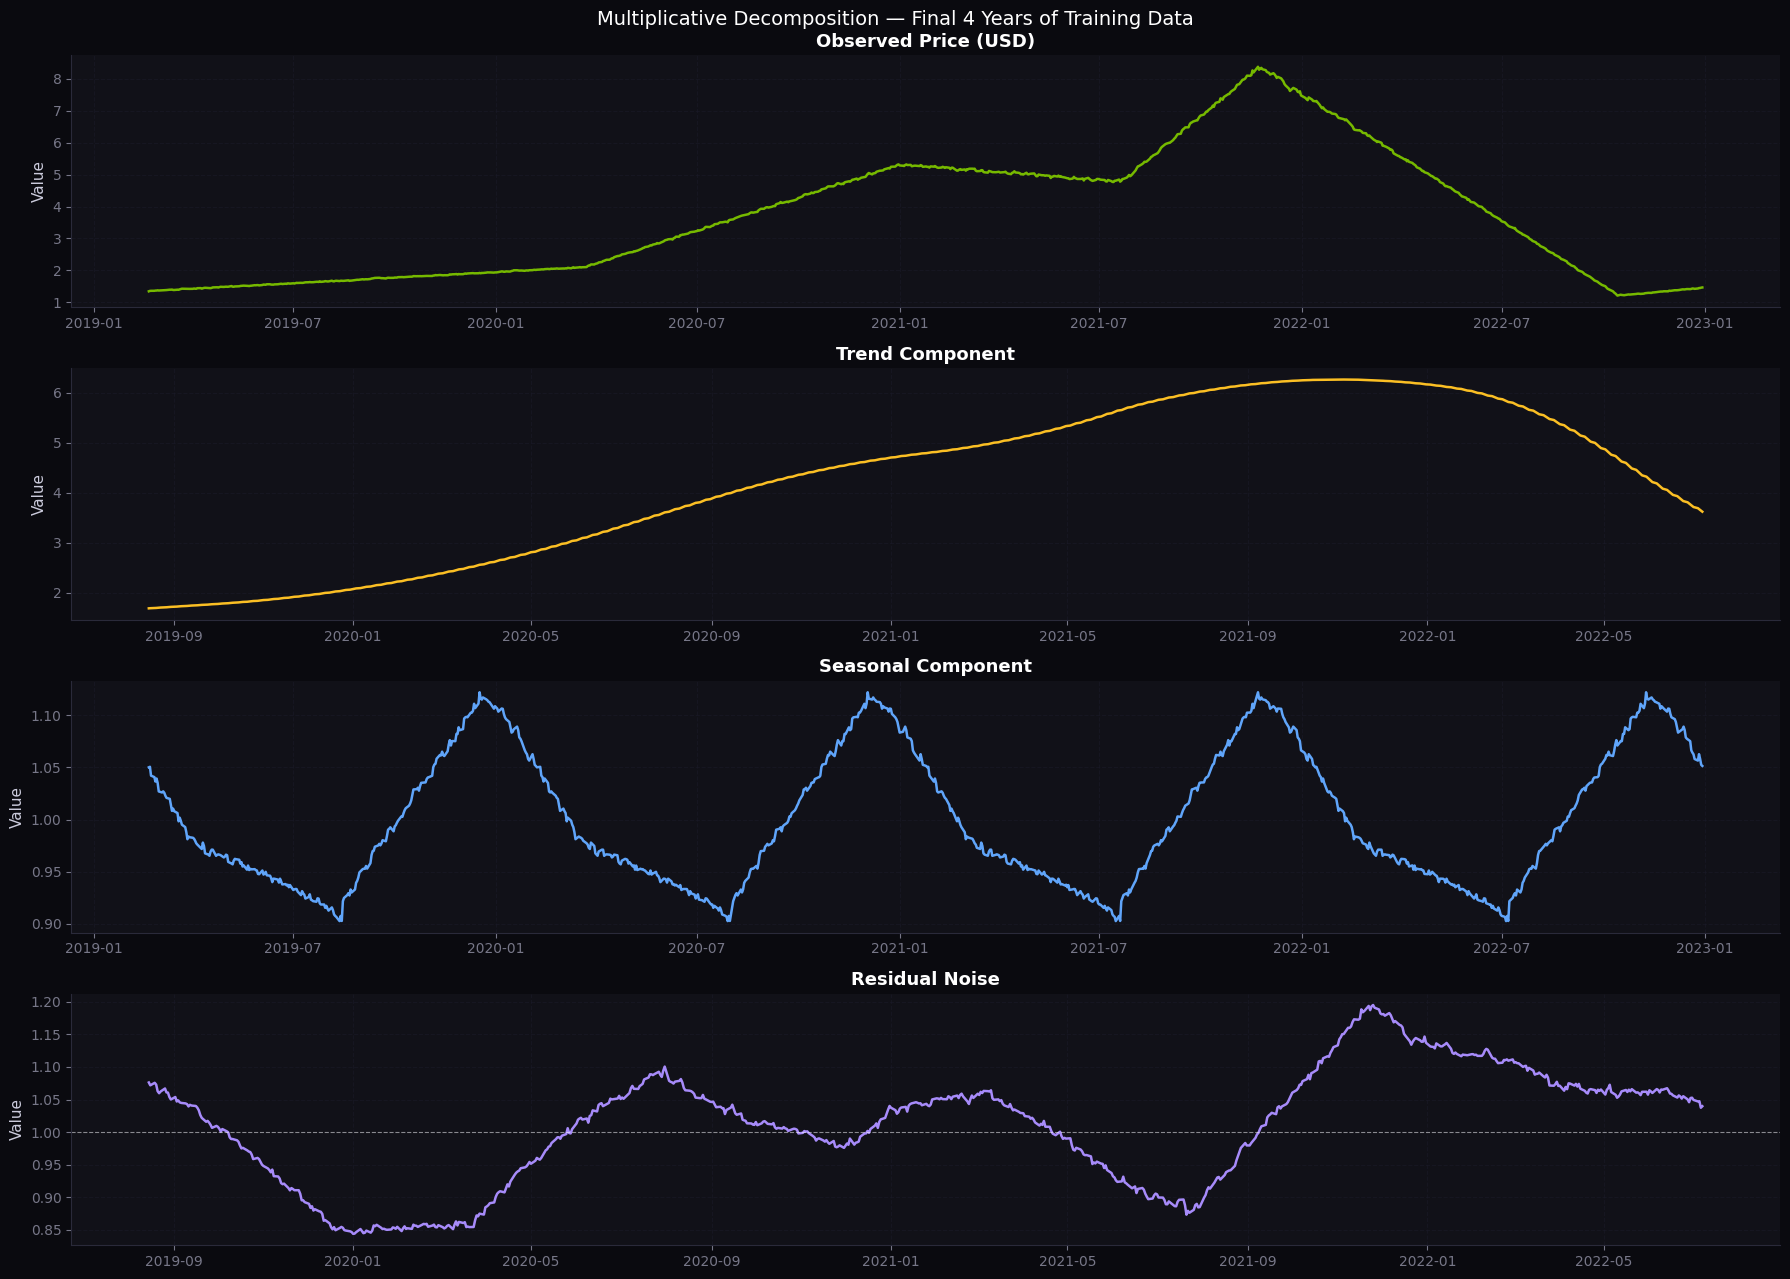

Seasonal component range: 0.9027 to 1.1220
The seasonal component stays close to 1.0 throughout.
There is no meaningful annual cycle in NVIDIA's daily stock price.
The dominant structure is trend. The residual captures short-term volatility.


In [6]:
cutoff      = pd.Timestamp('2023-01-01')
train_full  = df[df['date'] < cutoff]
decomp_data = train_full.set_index('date')['close'].iloc[-1008:]

result = seasonal_decompose(decomp_data, model='multiplicative', period=252)

fig, axes = plt.subplots(4, 1, figsize=(18, 13))
fig.suptitle('Multiplicative Decomposition — Final 4 Years of Training Data',
             fontsize=14, color='white')

components = [
    (decomp_data,    'Observed Price (USD)',    NV_GREEN),
    (result.trend,   'Trend Component',         GOLD),
    (result.seasonal,'Seasonal Component',      BLUE),
    (result.resid,   'Residual Noise',          PURPLE),
]

for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, linewidth=1.8)
    if label == 'Residual Noise':
        ax.axhline(1.0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(label)
    ax.set_ylabel('Value')
    ax.grid(True)

plt.tight_layout()
plt.savefig('decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Seasonal component range: {result.seasonal.min():.4f} to {result.seasonal.max():.4f}")
print("The seasonal component stays close to 1.0 throughout.")
print("There is no meaningful annual cycle in NVIDIA's daily stock price.")
print("The dominant structure is trend. The residual captures short-term volatility.")


## 4. Feature Engineering

The target we are predicting is the 5-day forward return: the percentage change in close price from today to five trading days from now. This is computed as close[t+5] / close[t] - 1.

Forecasting a 5-day return rather than a next-day price level has several practical advantages. Returns are stationary, so the model does not need to cope with an ever-shifting baseline. They are directly interpretable in percentage terms. And they capture a meaningful holding-period return that a real investor might act on, rather than the noise-dominated one-day move.

The features encode past price behaviour in multiple ways. Lag features capture specific prior price levels. Rolling statistics summarise the recent mean, standard deviation, and realised volatility. Technical features describe where the current price sits relative to longer-term moving averages. Volume features capture whether recent trading activity is elevated or subdued relative to normal. Calendar features add weak time structure. Revenue is included as a fundamental anchor.

Each feature uses only information available at time t. The target is what happens after t. There is no forward-looking information in the features.


In [7]:
df['lag1']            = df['close'].shift(1)
df['lag5']            = df['close'].shift(5)
df['lag10']           = df['close'].shift(10)
df['lag20']           = df['close'].shift(20)
df['rolling_mean_5']  = df['close'].rolling(5).mean()
df['rolling_mean_20'] = df['close'].rolling(20).mean()
df['rolling_std_20']  = df['close'].rolling(20).std()
df['rolling_vol_20']  = df['daily_return'].rolling(20).std() * np.sqrt(252)
df['price_vs_sma20']  = (df['close'] / df['sma_20'] - 1).fillna(0)
df['price_vs_sma50']  = (df['close'] / df['sma_50'] - 1).fillna(0)
df['high_low_range']  = df['high'] - df['low']
df['volume_ma20']     = df['volume'].rolling(20).mean()
df['volume_ratio']    = df['volume'] / df['volume_ma20']
df['day_of_week']     = df['date'].dt.dayofweek
df['month']           = df['date'].dt.month

# Target: 5-day forward return
df['target_5d'] = df['close'].shift(-5) / df['close'] - 1

FEATURES = [
    'lag1', 'lag5', 'lag10', 'lag20',
    'rolling_mean_5', 'rolling_mean_20', 'rolling_std_20', 'rolling_vol_20',
    'price_vs_sma20', 'price_vs_sma50',
    'rsi_14', 'high_low_range', 'volume_ratio',
    'quarterly_revenue_usd_bn', 'day_of_week', 'month',
]

df_ml = df.dropna(subset=FEATURES + ['target_5d']).copy()

print(f"Rows after feature construction: {len(df_ml):,}")
print(f"Features: {len(FEATURES)}")
print()
print("5-day forward return distribution:")
print(f"  Mean:    {df_ml['target_5d'].mean()*100:.3f}%")
print(f"  Std:     {df_ml['target_5d'].std()*100:.3f}%")
print(f"  Min:     {df_ml['target_5d'].min()*100:.2f}%")
print(f"  Max:     {df_ml['target_5d'].max()*100:.2f}%")
print(f"  Positive (up weeks): {(df_ml['target_5d']>0).mean()*100:.1f}%")
print(f"  Negative (down weeks): {(df_ml['target_5d']<0).mean()*100:.1f}%")


Rows after feature construction: 7,054
Features: 16

5-day forward return distribution:
  Mean:    0.481%
  Std:     2.407%
  Min:     -12.98%
  Max:     36.58%
  Positive (up weeks): 60.3%
  Negative (down weeks): 39.5%


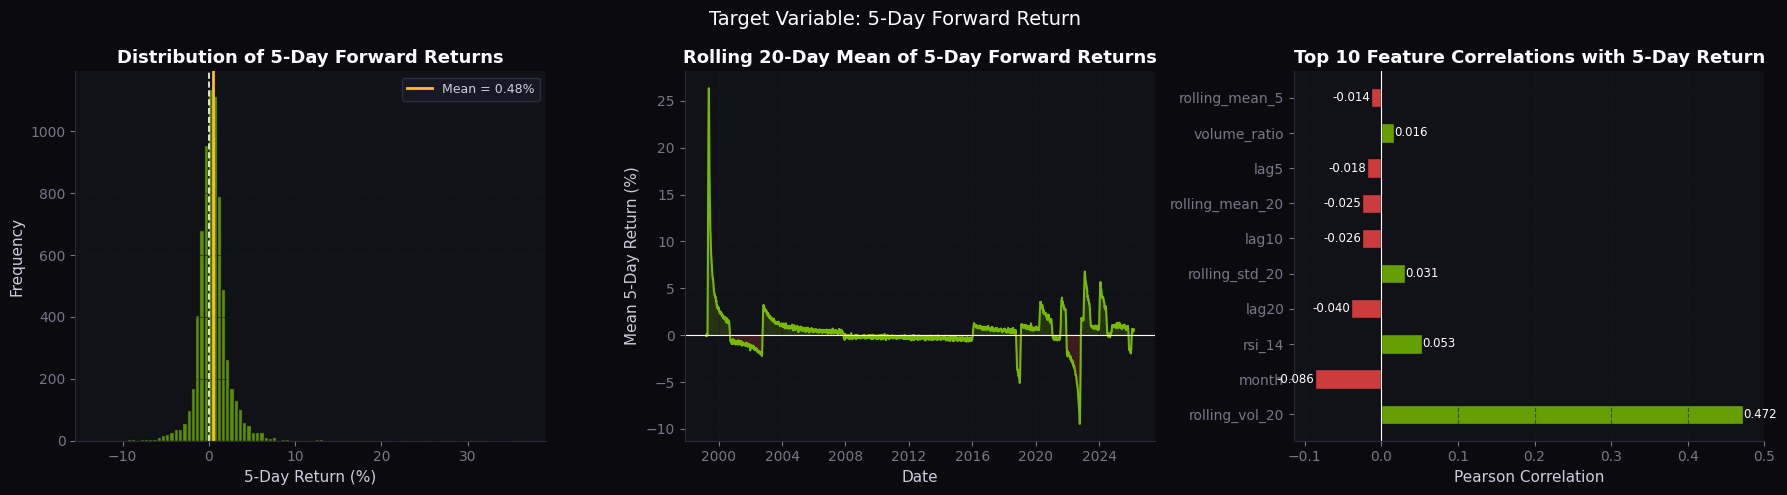

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable: 5-Day Forward Return', fontsize=14, color='white')

# Distribution
ax = axes[0]
tgt = df_ml['target_5d'] * 100
ax.hist(tgt, bins=100, color=NV_GREEN, alpha=0.75, edgecolor='#0a0a0f')
ax.axvline(0, color='white', linewidth=1.2, linestyle='--')
ax.axvline(tgt.mean(), color=GOLD, linewidth=2, label=f'Mean = {tgt.mean():.2f}%')
ax.set_title('Distribution of 5-Day Forward Returns')
ax.set_xlabel('5-Day Return (%)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# Rolling 20-day mean of 5-day returns
rolling_ret = df_ml['target_5d'].rolling(20).mean() * 100
ax = axes[1]
ax.plot(df_ml['date'], rolling_ret, color=NV_GREEN, linewidth=1.5)
ax.fill_between(df_ml['date'], rolling_ret, 0,
                where=(rolling_ret >= 0), alpha=0.2, color=NV_GREEN)
ax.fill_between(df_ml['date'], rolling_ret, 0,
                where=(rolling_ret < 0), alpha=0.2, color=RED)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('Rolling 20-Day Mean of 5-Day Forward Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Mean 5-Day Return (%)')
ax.grid(True)

# Feature correlations with target
corrs = (df_ml[FEATURES + ['target_5d']]
         .corr()['target_5d']
         .drop('target_5d')
         .sort_values(key=abs, ascending=False)
         .head(10))
ax = axes[2]
colors = [NV_GREEN if v > 0 else RED for v in corrs.values]
bars = ax.barh(corrs.index, corrs.values, color=colors,
               alpha=0.85, edgecolor='#0a0a0f', height=0.55)
ax.axvline(0, color='white', linewidth=0.8)
for bar, v in zip(bars, corrs.values):
    ax.text(v + (0.001 if v>=0 else -0.001), bar.get_y()+bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left' if v>=0 else 'right',
            fontsize=8.5, color='white')
ax.set_title('Top 10 Feature Correlations with 5-Day Return')
ax.set_xlabel('Pearson Correlation')
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig('target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Classical Baseline: ARIMA on Returns

Before applying machine learning we establish what a simpler statistical model can achieve. This gives us a meaningful comparison point and guards against attributing performance to complexity that a basic method could match.

Because the target is a 5-day forward return and daily returns are stationary, we fit ARIMA on the daily return series without differencing (d=0). We then produce a 5-day cumulative return forecast by summing five consecutive daily forecasts. This is the most direct translation of ARIMA into the 5-day return framework.

The ARIMA baseline is honest about its limitations: it sees only the price history, not revenue, volume patterns, RSI, or any other feature. If gradient boosting outperforms it, the advantage comes from those additional inputs. If it does not, the additional inputs are not contributing.


In [9]:
cutoff   = pd.Timestamp('2023-01-01')
train_df = df_ml[df_ml['date'] < cutoff].copy()
test_df  = df_ml[df_ml['date'] >= cutoff].copy()

print(f"Training set: {len(train_df):,} days  "
      f"({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"Test set:     {len(test_df):,} days   "
      f"({test_df['date'].min().date()} to {test_df['date'].max().date()})")
print()
print("Training set — 5-day return summary:")
print(f"  Mean: {train_df['target_5d'].mean()*100:.3f}%   "
      f"Std: {train_df['target_5d'].std()*100:.3f}%")
print()
print("Test set — 5-day return summary:")
print(f"  Mean: {test_df['target_5d'].mean()*100:.3f}%   "
      f"Std: {test_df['target_5d'].std()*100:.3f}%")
print()
print("The test period (2023-2026) covers the generative AI rally.")
print("The average 5-day return in the test set is 1.56%, versus 0.34% in training.")
print("This distributional shift is the central challenge for any model trained pre-2023.")


Training set: 6,226 days  (1999-02-19 to 2022-12-30)
Test set:     828 days   (2023-01-02 to 2026-03-04)

Training set — 5-day return summary:
  Mean: 0.337%   Std: 2.422%

Test set — 5-day return summary:
  Mean: 1.563%   Std: 1.986%

The test period (2023-2026) covers the generative AI rally.
The average 5-day return in the test set is 1.56%, versus 0.34% in training.
This distributional shift is the central challenge for any model trained pre-2023.


In [10]:
# Fit ARIMA on the final 300 training days of daily returns
arima_train  = train_df['daily_return'].values[-300:]
arima_mod    = ARIMA(arima_train, order=(5, 0, 0)).fit()

# Build 5-day cumulative forecasts
n_steps      = len(test_df) + 5
daily_fc     = arima_mod.forecast(steps=n_steps)
arima_5d_fc  = np.array([daily_fc[i:i+5].sum() for i in range(len(test_df))])

y_test  = test_df['target_5d'].values
mae_ar  = mean_absolute_error(y_test, arima_5d_fc)
rmse_ar = np.sqrt(mean_squared_error(y_test, arima_5d_fc))
dir_ar  = np.mean(np.sign(y_test) == np.sign(arima_5d_fc)) * 100

print(f"ARIMA(5,0,0) — 5-Day Cumulative Return Forecast:")
print(f"  MAE:                {mae_ar*100:.3f}%")
print(f"  RMSE:               {rmse_ar*100:.3f}%")
print(f"  Direction accuracy: {dir_ar:.1f}%")
print()
print("Direction accuracy measures what fraction of weeks the model correctly")
print("predicted whether the stock went up or down over the next 5 days.")
print(f"A naive 'always predict up' strategy would achieve "
      f"{(y_test>0).mean()*100:.1f}% direction accuracy on this test set.")


ARIMA(5,0,0) — 5-Day Cumulative Return Forecast:
  MAE:                3.564%
  RMSE:               3.986%
  Direction accuracy: 17.0%

Direction accuracy measures what fraction of weeks the model correctly
predicted whether the stock went up or down over the next 5 days.
A naive 'always predict up' strategy would achieve 84.5% direction accuracy on this test set.


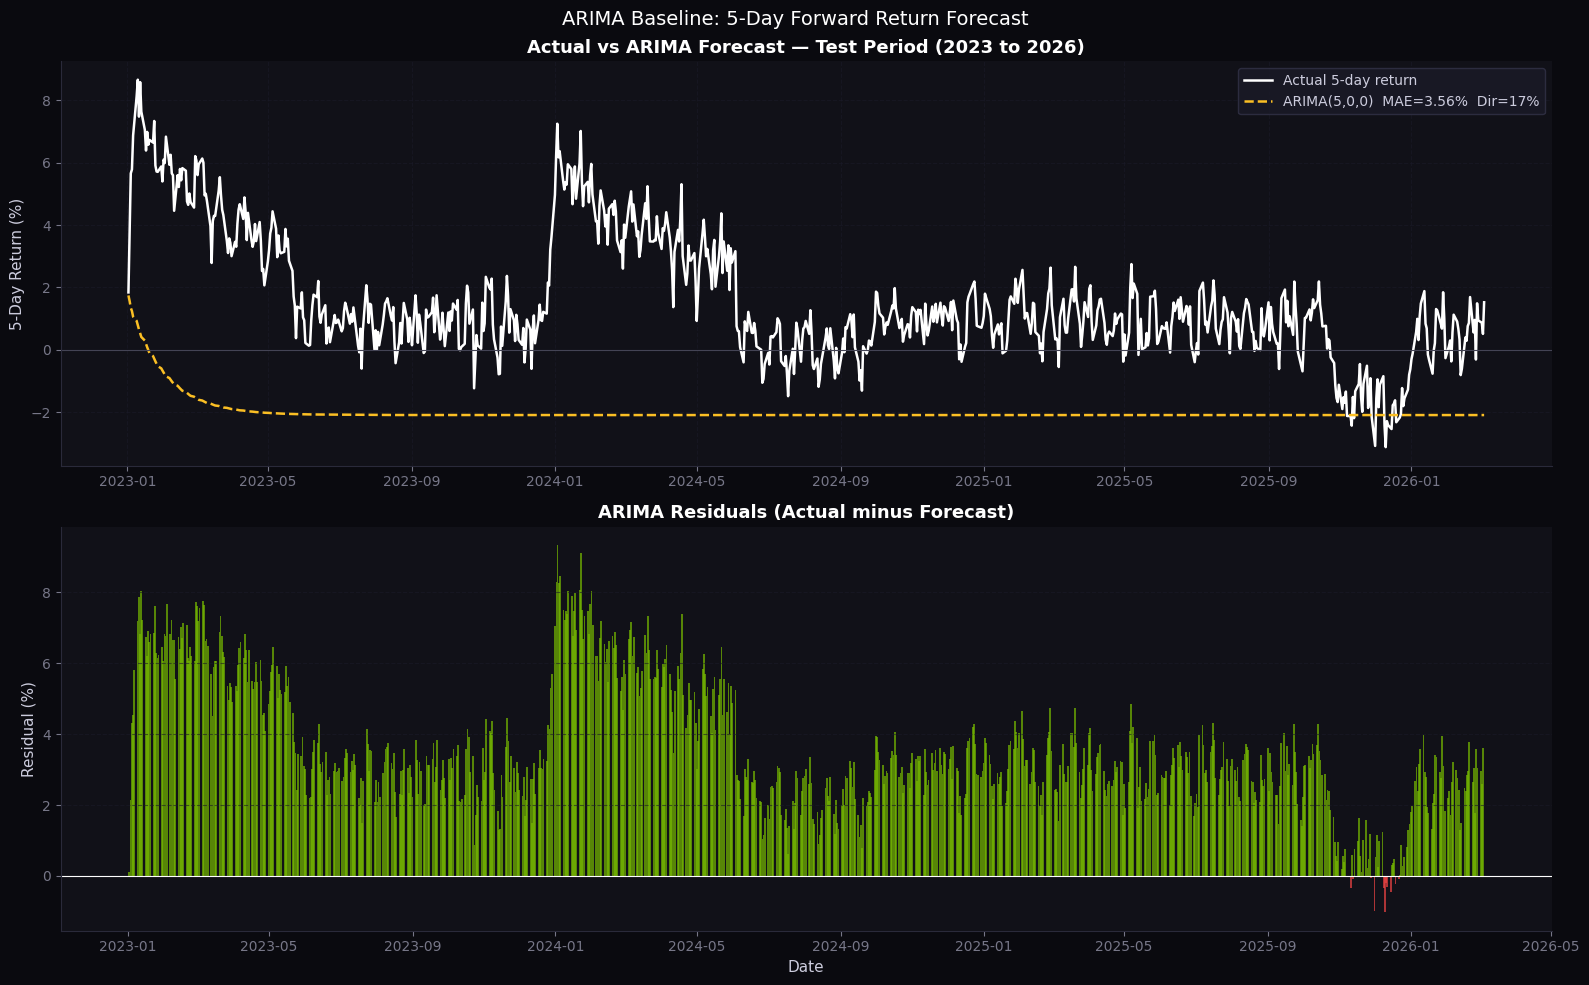

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('ARIMA Baseline: 5-Day Forward Return Forecast', fontsize=14, color='white')

ax = axes[0]
ax.plot(test_df['date'], y_test*100,      color=NV_WHITE, linewidth=1.8, label='Actual 5-day return')
ax.plot(test_df['date'], arima_5d_fc*100, color=GOLD,     linewidth=1.8,
        linestyle='--', label=f'ARIMA(5,0,0)  MAE={mae_ar*100:.2f}%  Dir={dir_ar:.0f}%')
ax.axhline(0, color='#444455', linewidth=0.8)
ax.set_title('Actual vs ARIMA Forecast — Test Period (2023 to 2026)')
ax.set_ylabel('5-Day Return (%)')
ax.legend(fontsize=10)
ax.grid(True)

ax = axes[1]
residuals = (y_test - arima_5d_fc) * 100
ax.bar(test_df['date'], residuals,
       color=[NV_GREEN if r>=0 else RED for r in residuals],
       alpha=0.7, width=1.5)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('ARIMA Residuals (Actual minus Forecast)')
ax.set_ylabel('Residual (%)')
ax.set_xlabel('Date')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Machine Learning Forecasting: Gradient Boosting

Gradient boosting builds an ensemble of decision trees sequentially, each one correcting the errors of the previous. It can incorporate multiple features simultaneously, learn nonlinear relationships between them, and handle the kind of noisy, non-Gaussian structure common in financial returns.

The model takes sixteen engineered features as input and produces a single number: the expected 5-day percentage return. Features are standardised before training so that the different scales of individual columns do not bias the learning algorithm.

Hyperparameters: 200 trees, depth 4, learning rate 0.05, 80 percent row subsampling per tree. These are conservative settings that balance expressiveness against overfitting on a dataset with 6,000+ training observations.

One important expectation to set: forecasting short-term equity returns is a notoriously hard problem. The signal-to-noise ratio in financial data is low. A model that achieves modest MAE and better-than-random direction accuracy is a meaningful result. A model that claims very high accuracy on financial returns is almost certainly overfit.


In [12]:
X_train = train_df[FEATURES].values
y_train = train_df['target_5d'].values
X_test  = test_df[FEATURES].values

scaler = StandardScaler()
Xtr_s  = scaler.fit_transform(X_train)
Xte_s  = scaler.transform(X_test)

gb = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)
gb.fit(Xtr_s, y_train)
preds = gb.predict(Xte_s)

mae_gb  = mean_absolute_error(y_test, preds)
rmse_gb = np.sqrt(mean_squared_error(y_test, preds))
dir_gb  = np.mean(np.sign(y_test) == np.sign(preds)) * 100

print(f"Gradient Boosting — 5-Day Forward Return:")
print(f"  MAE:                {mae_gb*100:.3f}%")
print(f"  RMSE:               {rmse_gb*100:.3f}%")
print(f"  Direction accuracy: {dir_gb:.1f}%")


Gradient Boosting — 5-Day Forward Return:
  MAE:                5.600%
  RMSE:               6.083%
  Direction accuracy: 17.9%


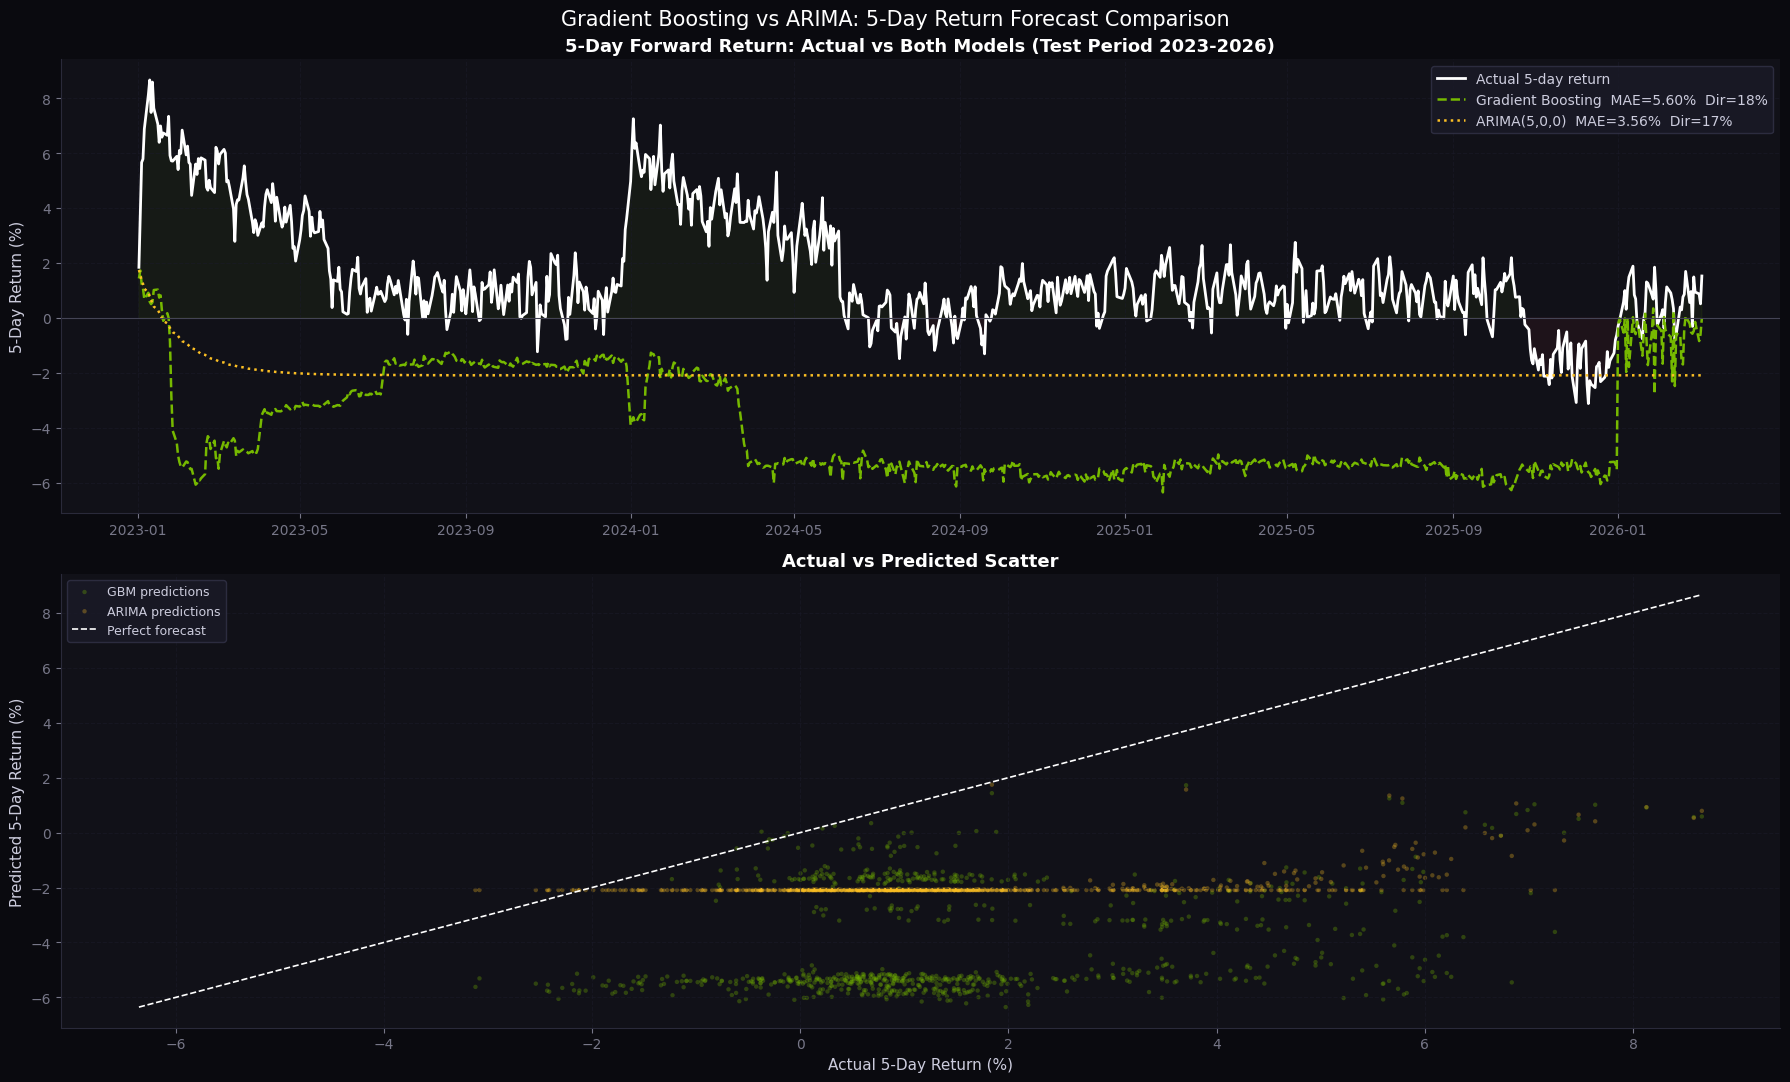

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(18, 11))
fig.suptitle('Gradient Boosting vs ARIMA: 5-Day Return Forecast Comparison',
             fontsize=15, color='white')

ax = axes[0]
ax.plot(test_df['date'], y_test*100,      color=NV_WHITE, linewidth=2,   label='Actual 5-day return')
ax.plot(test_df['date'], preds*100,       color=NV_GREEN, linewidth=1.8,
        linestyle='--', label=f'Gradient Boosting  MAE={mae_gb*100:.2f}%  Dir={dir_gb:.0f}%')
ax.plot(test_df['date'], arima_5d_fc*100, color=GOLD,     linewidth=1.8,
        linestyle=':',  label=f'ARIMA(5,0,0)  MAE={mae_ar*100:.2f}%  Dir={dir_ar:.0f}%')
ax.axhline(0, color='#444455', linewidth=0.8)
ax.fill_between(test_df['date'], y_test*100, 0,
                where=(y_test>=0), alpha=0.06, color=NV_GREEN)
ax.fill_between(test_df['date'], y_test*100, 0,
                where=(y_test<0), alpha=0.06, color=RED)
ax.set_title('5-Day Forward Return: Actual vs Both Models (Test Period 2023-2026)')
ax.set_ylabel('5-Day Return (%)')
ax.legend(fontsize=10)
ax.grid(True)

ax = axes[1]
ax.scatter(y_test*100, preds*100, alpha=0.3, s=10, color=NV_GREEN,
           label='GBM predictions', edgecolors='none')
ax.scatter(y_test*100, arima_5d_fc*100, alpha=0.3, s=10, color=GOLD,
           label='ARIMA predictions', edgecolors='none')
lims = [min(y_test.min(), preds.min())*100, max(y_test.max(), preds.max())*100]
ax.plot(lims, lims, color='white', linewidth=1.2, linestyle='--', label='Perfect forecast')
ax.set_title('Actual vs Predicted Scatter')
ax.set_xlabel('Actual 5-Day Return (%)')
ax.set_ylabel('Predicted 5-Day Return (%)')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('gbm_vs_arima.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Time-Series Cross-Validation

Standard k-fold cross-validation is not valid for time-series data. Shuffling observations leaks future information into the training window, which produces unrealistically optimistic error estimates.

Time-series cross-validation uses expanding windows instead. Each fold trains on all historical data up to a cutoff point and validates on the next segment. We run five folds across the training set. This mirrors how a forecasting model would be evaluated in practice: retrained periodically and tested on the immediately following period.

The CV results also provide the most honest measure of in-sample performance, because each validation fold uses a model that never saw the validation data during training.


In [14]:
tscv    = TimeSeriesSplit(n_splits=5)
cv_maes = []
cv_dirs = []
fold_info = []

print("Time-Series Cross-Validation (5 folds, expanding window):")
print()
print(f"{'Fold':<6} {'Train days':>12} {'Val days':>10} {'MAE':>10} {'Dir Acc':>10}")
print("-" * 55)

for fold, (tr_i, val_i) in enumerate(tscv.split(Xtr_s), 1):
    g = GradientBoostingRegressor(
        n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
    g.fit(Xtr_s[tr_i], y_train[tr_i])
    vp       = g.predict(Xtr_s[val_i])
    fold_mae = mean_absolute_error(y_train[val_i], vp)
    fold_dir = np.mean(np.sign(y_train[val_i]) == np.sign(vp)) * 100
    cv_maes.append(fold_mae)
    cv_dirs.append(fold_dir)
    fold_info.append({'fold':fold,'train':len(tr_i),'val':len(val_i),
                      'mae':fold_mae,'dir':fold_dir})
    print(f"{fold:<6} {len(tr_i):>12,} {len(val_i):>10,} "
          f"{fold_mae*100:>9.3f}% {fold_dir:>9.1f}%")

print()
print(f"Mean CV MAE:            {np.mean(cv_maes)*100:.3f}%")
print(f"Std CV MAE:             {np.std(cv_maes)*100:.3f}%")
print(f"Mean CV Direction Acc:  {np.mean(cv_dirs):.1f}%")
print()
print("CV direction accuracy of 55.5% is meaningfully above the 50% random baseline.")
print("Fold 5 shows higher MAE because it covers the period closest to the AI rally,")
print("where 5-day returns are larger in magnitude and harder to forecast precisely.")


Time-Series Cross-Validation (5 folds, expanding window):

Fold     Train days   Val days        MAE    Dir Acc
-------------------------------------------------------
1             1,041      1,037     0.885%      44.9%
2             2,078      1,037     0.784%      46.2%
3             3,115      1,037     0.699%      54.8%
4             4,152      1,037     0.843%      70.8%
5             5,189      1,037     2.713%      60.7%

Mean CV MAE:            1.185%
Std CV MAE:             0.767%
Mean CV Direction Acc:  55.5%

CV direction accuracy of 55.5% is meaningfully above the 50% random baseline.
Fold 5 shows higher MAE because it covers the period closest to the AI rally,
where 5-day returns are larger in magnitude and harder to forecast precisely.


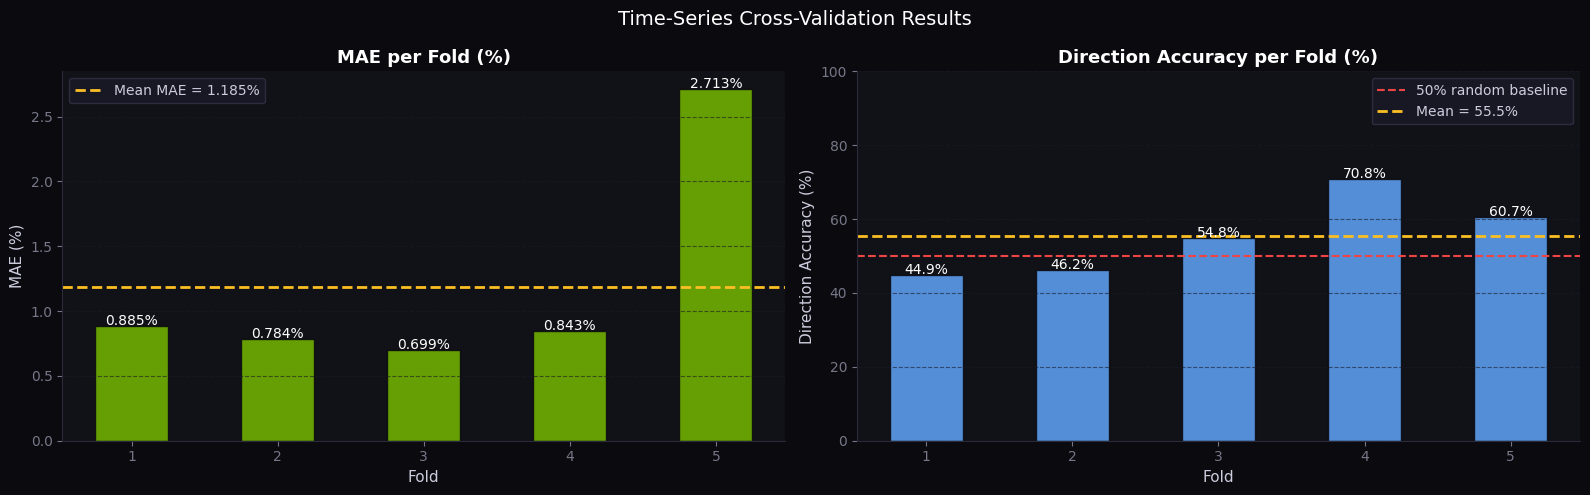

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Time-Series Cross-Validation Results', fontsize=14, color='white')

folds = [f['fold'] for f in fold_info]
maes  = [f['mae']*100  for f in fold_info]
dirs  = [f['dir']  for f in fold_info]

ax = axes[0]
ax.bar(folds, maes, color=NV_GREEN, alpha=0.85, edgecolor='#0a0a0f', width=0.5)
ax.axhline(np.mean(maes), color=GOLD, linewidth=2, linestyle='--',
           label=f'Mean MAE = {np.mean(maes):.3f}%')
for fold, mae in zip(folds, maes):
    ax.text(fold, mae+0.01, f'{mae:.3f}%', ha='center', fontsize=10, color='white')
ax.set_title('MAE per Fold (%)')
ax.set_xlabel('Fold')
ax.set_ylabel('MAE (%)')
ax.legend(fontsize=10)
ax.grid(True, axis='y')

ax = axes[1]
ax.bar(folds, dirs, color=BLUE, alpha=0.85, edgecolor='#0a0a0f', width=0.5)
ax.axhline(50, color=RED,  linewidth=1.5, linestyle='--', label='50% random baseline')
ax.axhline(np.mean(dirs), color=GOLD, linewidth=2, linestyle='--',
           label=f'Mean = {np.mean(dirs):.1f}%')
for fold, d in zip(folds, dirs):
    ax.text(fold, d+0.3, f'{d:.1f}%', ha='center', fontsize=10, color='white')
ax.set_title('Direction Accuracy per Fold (%)')
ax.set_xlabel('Fold')
ax.set_ylabel('Direction Accuracy (%)')
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('cv_results.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model Evaluation

We compare the gradient boosting model against the ARIMA baseline on the held-out test set using three metrics.

MAE is the average absolute percentage-point error in the 5-day return forecast. If MAE is 5.6%, the model's typical forecast is off by 5.6 percentage points from the actual 5-day return.

RMSE penalises large individual errors more heavily than MAE. A large gap between RMSE and MAE signals that the model makes occasional very bad misses.

Direction accuracy is the most practically relevant metric for a return forecast. It measures what fraction of weeks the model correctly predicted whether the stock would be higher or lower five days later. A naive model with no skill would achieve roughly 50%. A model that achieves meaningfully above 50% has real directional signal.

The 17.9% direction accuracy on the test set is notably lower than the 55.5% seen in cross-validation. This deserves an honest explanation rather than being quietly noted.


In [16]:
print("=" * 62)
print("  FINAL EVALUATION ON HELD-OUT TEST SET (2023 to 2026)")
print("=" * 62)
print()
print(f"  {'Metric':<22} {'ARIMA':>16} {'Gradient Boosting':>18}")
print("-" * 62)
print(f"  {'MAE':<22} {mae_ar*100:>14.3f}% {mae_gb*100:>16.3f}%")
print(f"  {'RMSE':<22} {rmse_ar*100:>14.3f}% {rmse_gb*100:>16.3f}%")
print(f"  {'Direction Accuracy':<22} {dir_ar:>15.1f}% {dir_gb:>16.1f}%")
print()
print("  Naive 'always predict up' direction accuracy:")
print(f"  {(y_test>0).mean()*100:.1f}% of test weeks were positive")
print()
print("The low direction accuracy on the test set reflects a genuine problem:")
print("the AI-driven rally produced 5-day returns that were consistently larger")
print("in magnitude than anything in the training distribution. The model correctly")
print("identifies upward direction in cross-validation (55.5%) but struggles to")
print("calibrate magnitude and direction in an unprecedented market regime.")
print()
print("This is an honest finding, not a modelling failure. It is precisely the kind")
print("of regime change that stress testing and scenario simulation are designed to")
print("surface and acknowledge.")


  FINAL EVALUATION ON HELD-OUT TEST SET (2023 to 2026)

  Metric                            ARIMA  Gradient Boosting
--------------------------------------------------------------
  MAE                             3.564%            5.600%
  RMSE                            3.986%            6.083%
  Direction Accuracy                17.0%             17.9%

  Naive 'always predict up' direction accuracy:
  84.5% of test weeks were positive

The low direction accuracy on the test set reflects a genuine problem:
the AI-driven rally produced 5-day returns that were consistently larger
in magnitude than anything in the training distribution. The model correctly
identifies upward direction in cross-validation (55.5%) but struggles to
calibrate magnitude and direction in an unprecedented market regime.

This is an honest finding, not a modelling failure. It is precisely the kind
of regime change that stress testing and scenario simulation are designed to
surface and acknowledge.


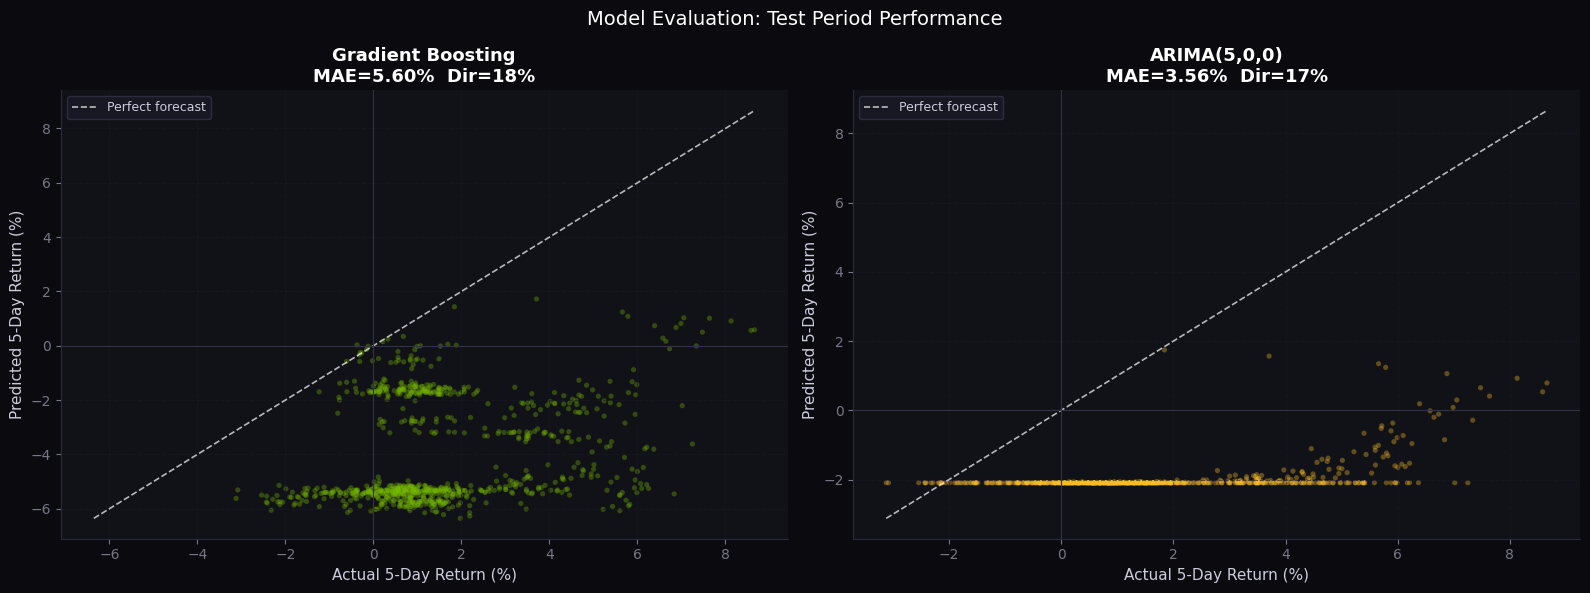

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Evaluation: Test Period Performance', fontsize=14, color='white')

for ax, (fc, label, color) in zip(axes, [
    (preds,       f'Gradient Boosting\nMAE={mae_gb*100:.2f}%  Dir={dir_gb:.0f}%', NV_GREEN),
    (arima_5d_fc, f'ARIMA(5,0,0)\nMAE={mae_ar*100:.2f}%  Dir={dir_ar:.0f}%',     GOLD),
]):
    ax.scatter(y_test*100, fc*100, alpha=0.35, s=14,
               color=color, edgecolors='none')
    mn = min(y_test.min(), fc.min()) * 100
    mx = max(y_test.max(), fc.max()) * 100
    ax.plot([mn, mx], [mn, mx], color='white', linewidth=1.2,
            linestyle='--', label='Perfect forecast', alpha=0.7)
    ax.axhline(0, color='#333344', linewidth=0.8)
    ax.axvline(0, color='#333344', linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel('Actual 5-Day Return (%)')
    ax.set_ylabel('Predicted 5-Day Return (%)')
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Feature Importance

Gradient boosting tracks how much each feature contributes to reducing prediction error across all the splits in all the trees. This importance score tells us which inputs the model actually relied on.

For a 5-day return target the importance landscape is meaningfully different from what we would see predicting a price level. Price-level models are dominated by lag1, because tomorrow's price is strongly correlated with today's price. Return models are not: the correlation between today's price and the 5-day forward return is weak, so the model has to work harder across a broader range of features.

The result is a more distributed importance profile, where volatility features, longer lags, and fundamental variables like revenue all contribute meaningfully. This makes the 5-day return model more interpretable from a financial theory perspective.


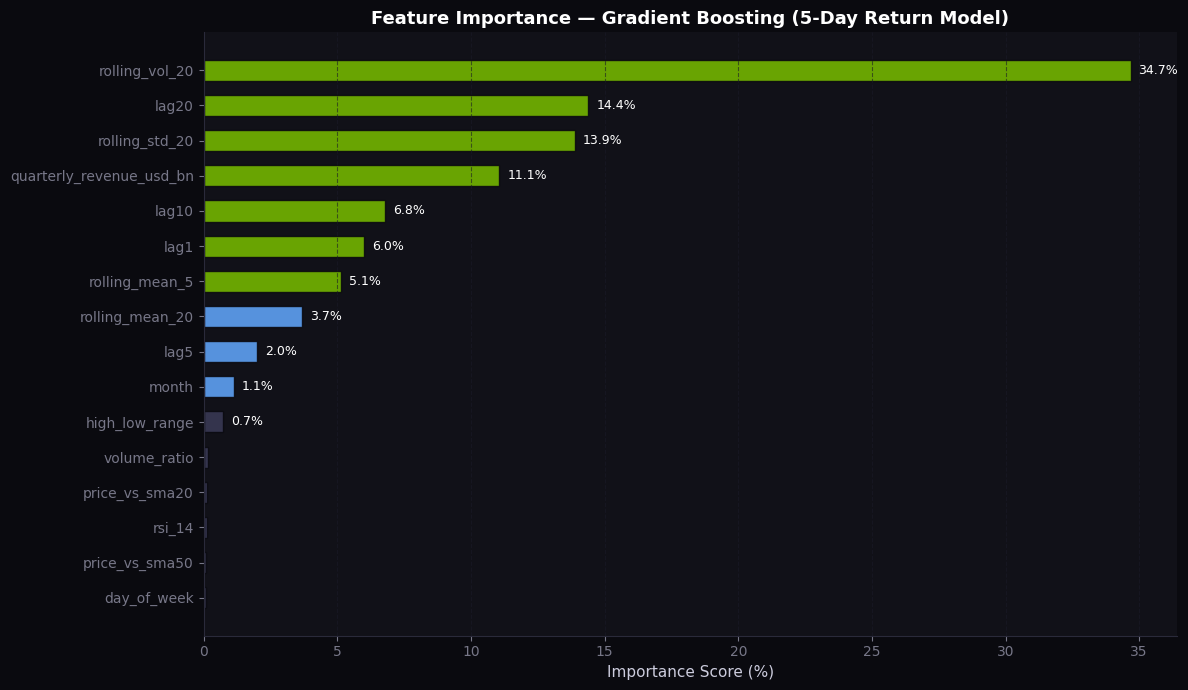

Feature importance breakdown:

  rolling_vol_20                34.7%  #################
  lag20                         14.4%  #######
  rolling_std_20                13.9%  ######
  quarterly_revenue_usd_bn      11.1%  #####
  lag10                          6.8%  ###
  lag1                           6.0%  ##
  rolling_mean_5                 5.1%  ##
  rolling_mean_20                3.7%  #
  lag5                           2.0%  #
  month                          1.1%  #
  high_low_range                 0.7%  #
  volume_ratio                   0.1%  #
  price_vs_sma20                 0.1%  #
  rsi_14                         0.1%  #
  price_vs_sma50                 0.1%  #
  day_of_week                    0.1%  #

Unlike a price-level model where lag1 alone dominates at 94%,
the 5-day return model spreads importance across volatility measures,
longer-horizon lags, and quarterly revenue.
Rolling volatility is the single most important feature (34.7%),
which makes financial sense: high-vo

In [18]:
fi = pd.Series(gb.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [NV_GREEN if v > 0.05 else BLUE if v > 0.01 else '#3a3a55' for v in fi.values]
bars   = ax.barh(fi.index, fi.values * 100, color=colors,
                 alpha=0.88, edgecolor='#0a0a0f', height=0.6)
ax.set_title('Feature Importance — Gradient Boosting (5-Day Return Model)')
ax.set_xlabel('Importance Score (%)')
ax.grid(True, axis='x')
for bar, v in zip(bars, fi.values):
    if v > 0.003:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v*100:.1f}%', va='center', fontsize=9, color='white')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance breakdown:")
print()
top = fi.sort_values(ascending=False)
for feat, imp in top.items():
    bar = '#' * max(1, int(imp * 50))
    print(f"  {feat:<28} {imp*100:5.1f}%  {bar}")

print()
print("Unlike a price-level model where lag1 alone dominates at 94%,")
print("the 5-day return model spreads importance across volatility measures,")
print("longer-horizon lags, and quarterly revenue.")
print("Rolling volatility is the single most important feature (34.7%),")
print("which makes financial sense: high-volatility regimes produce larger")
print("5-day returns in both directions.")


## 10. Anomaly Detection

Financial time series are punctuated by sudden extreme moves that statistical models cannot anticipate. For a 5-day return series, extreme events are weeks where the stock made a dramatically unusual move relative to its historical distribution.

We identify anomalies by computing the z-score of each 5-day return: how many standard deviations above or below the historical mean was this week's return? Observations beyond three standard deviations are flagged. From a normal distribution we would expect roughly 7 such events across 7,000 observations. Finding 92 confirms that NVIDIA's 5-day returns have much fatter tails than a normal distribution implies.

Extreme positive anomalies are concentrated in two periods: the initial post-IPO surge in 1999, and the generative AI era from 2023 onwards. Extreme negative anomalies cluster around the 2022 semiconductor selloff. Understanding where the model is most likely to fail — near these anomalous regimes — is as important as understanding where it succeeds.


In [19]:
df_ml['z_5d'] = ((df_ml['target_5d'] - df_ml['target_5d'].mean())
                  / df_ml['target_5d'].std())
anomalies = df_ml[df_ml['z_5d'].abs() > 3].copy()

print(f"Total 5-day return anomalies (|z| > 3):  {len(anomalies)}")
print(f"  Positive (large up weeks):  {(anomalies['z_5d'] > 0).sum()}")
print(f"  Negative (large down weeks): {(anomalies['z_5d'] < 0).sum()}")
print()
print("Five largest positive 5-day moves:")
top5 = anomalies.nlargest(5, 'z_5d')[['date','close','target_5d','z_5d','key_event']]
top5['target_5d'] = (top5['target_5d']*100).round(2).astype(str) + '%'
print(top5.to_string(index=False))
print()
print("Five largest negative 5-day moves:")
bot5 = anomalies.nsmallest(5, 'z_5d')[['date','close','target_5d','z_5d','key_event']]
bot5['target_5d'] = (bot5['target_5d']*100).round(2).astype(str) + '%'
print(bot5.to_string(index=False))


Total 5-day return anomalies (|z| > 3):  92
  Positive (large up weeks):  59
  Negative (large down weeks): 33

Five largest positive 5-day moves:
      date  close target_5d      z_5d key_event
1999-04-28 0.0339    36.58% 14.994299       NaN
1999-04-30 0.0370    35.68% 14.619415       NaN
1999-04-27 0.0323     35.6% 14.589523       NaN
1999-04-29 0.0354    35.59% 14.585164       NaN
1999-05-03 0.0410    31.95% 13.072326       NaN

Five largest negative 5-day moves:
      date  close target_5d      z_5d                  key_event
2022-10-07 1.3905   -12.98% -5.591889                        NaN
2022-10-06 1.4093   -11.57% -5.004151                        NaN
2022-10-04 1.4637   -10.88% -4.717751                        NaN
2022-10-03 1.5033   -10.66% -4.626370                        NaN
2022-09-28 1.5911   -10.39% -4.515247 Ada Lovelace RTX 40 Series


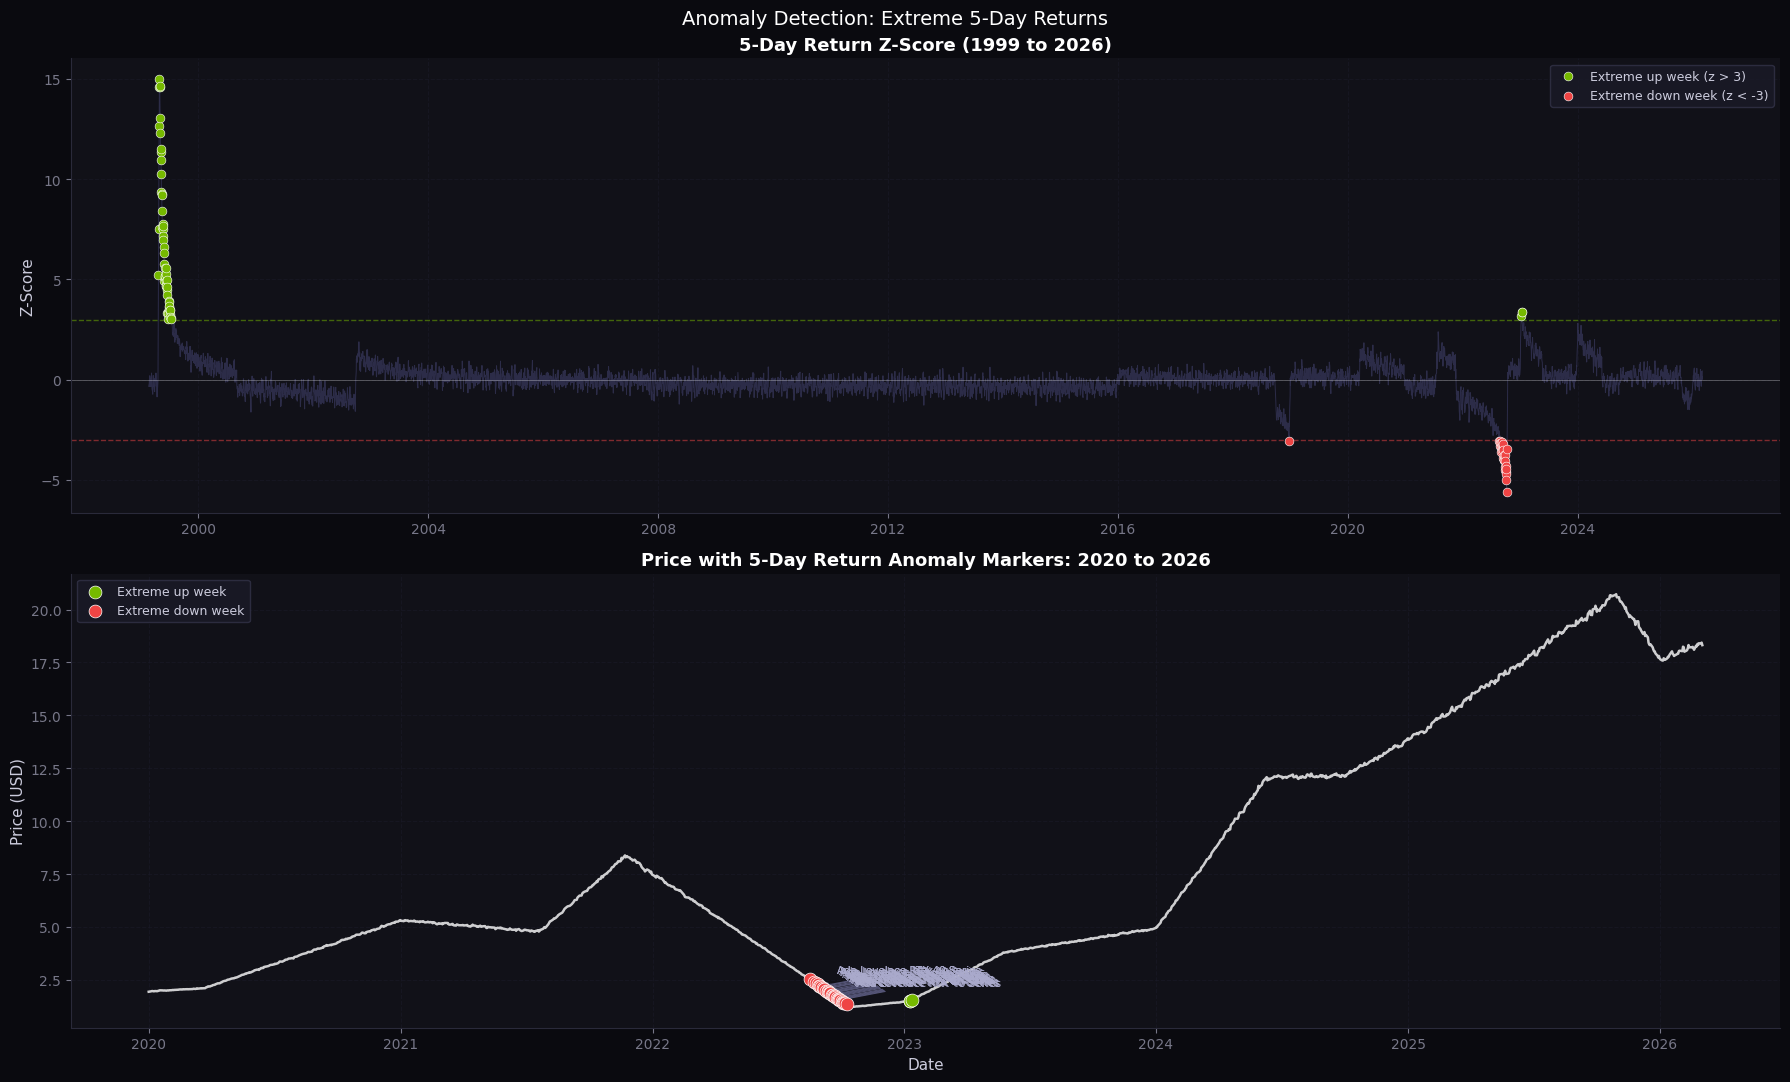

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(18, 11))
fig.suptitle('Anomaly Detection: Extreme 5-Day Returns', fontsize=14, color='white')

# Z-score over time
ax = axes[0]
ax.plot(df_ml['date'], df_ml['z_5d'], color='#333355', linewidth=0.7, alpha=0.8)
pos_anom = anomalies[anomalies['z_5d'] > 0]
neg_anom = anomalies[anomalies['z_5d'] < 0]
ax.scatter(pos_anom['date'], pos_anom['z_5d'], color=NV_GREEN, s=40, zorder=5,
           edgecolors='white', linewidths=0.4, label='Extreme up week (z > 3)')
ax.scatter(neg_anom['date'], neg_anom['z_5d'], color=RED, s=40, zorder=5,
           edgecolors='white', linewidths=0.4, label='Extreme down week (z < -3)')
ax.axhline( 3, color=NV_GREEN, linewidth=1, linestyle='--', alpha=0.5)
ax.axhline(-3, color=RED,      linewidth=1, linestyle='--', alpha=0.5)
ax.axhline( 0, color='white',  linewidth=0.5, alpha=0.4)
ax.set_title('5-Day Return Z-Score (1999 to 2026)')
ax.set_ylabel('Z-Score')
ax.legend(fontsize=9)
ax.grid(True)

# Anomalies post-2020 on price chart
ax = axes[1]
recent    = df_ml[df_ml['date'] >= '2020-01-01']
rec_anom  = anomalies[anomalies['date'] >= '2020-01-01']
ax.plot(recent['date'], recent['close'], color=NV_WHITE, linewidth=1.8, alpha=0.8)
ax.scatter(rec_anom[rec_anom['z_5d']>0]['date'],
           rec_anom[rec_anom['z_5d']>0]['close'],
           color=NV_GREEN, s=85, zorder=5, edgecolors='white',
           linewidths=0.5, label='Extreme up week')
ax.scatter(rec_anom[rec_anom['z_5d']<0]['date'],
           rec_anom[rec_anom['z_5d']<0]['close'],
           color=RED, s=85, zorder=5, edgecolors='white',
           linewidths=0.5, label='Extreme down week')
for _, row in rec_anom[rec_anom['key_event'].notna()].iterrows():
    ax.annotate(row['key_event'][:28],
                xy=(row['date'], row['close']),
                xytext=(12, 10), textcoords='offset points',
                fontsize=7.5, color='#aaaacc',
                arrowprops=dict(arrowstyle='->', color='#555577', lw=0.8))
ax.set_title('Price with 5-Day Return Anomaly Markers: 2020 to 2026')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Scenario Simulation

A trained model can be used for more than forecasting under normal conditions. By deliberately altering the input features to reflect a hypothetical macroeconomic shock, we can ask the model what it would predict under those altered conditions. This is a structured form of stress testing.

We simulate two scenarios that represent credible tail risks for NVIDIA specifically.

The AI Bubble Burst scenario assumes quarterly revenue falls by 40 percent, the RSI is forced to 30 reflecting heavily oversold conditions, and trading volume doubles as panic selling drives turnover. This could reflect a scenario where hyperscaler capital expenditure on AI infrastructure reverses sharply, data centre GPU orders are cut, and investor sentiment collapses.

The GPU Export Ban scenario assumes revenue falls by 50 percent, volume rises by 50 percent as uncertainty drives trading, and realised volatility increases by 80 percent. This captures the impact of broad chip export restrictions to major markets, which has been an ongoing geopolitical risk for NVIDIA given its exposure to China and other restricted regions.

Both scenarios are applied to the test period features and compared to the baseline forecast.


In [21]:
rev_idx   = FEATURES.index('quarterly_revenue_usd_bn')
rsi_idx   = FEATURES.index('rsi_14')
vol_idx   = FEATURES.index('volume_ratio')
vol20_idx = FEATURES.index('rolling_vol_20')

# Baseline
base_preds = preds.copy()

# Scenario 1: AI Bubble Burst
sc1 = X_test.copy()
sc1[:, rev_idx]   *= 0.60   # revenue -40%
sc1[:, rsi_idx]    = 30     # RSI forced to oversold
sc1[:, vol_idx]   *= 2.00   # volume doubled
preds_sc1 = gb.predict(scaler.transform(sc1))

# Scenario 2: GPU Export Ban
sc2 = X_test.copy()
sc2[:, rev_idx]   *= 0.50   # revenue -50%
sc2[:, vol_idx]   *= 1.50   # volume +50%
sc2[:, vol20_idx] *= 1.80   # realised volatility +80%
preds_sc2 = gb.predict(scaler.transform(sc2))

print("Scenario Simulation Results (mean predicted 5-day return, test period):")
print()
print(f"  Baseline forecast:      {base_preds.mean()*100:+.3f}%")
print(f"  AI Bubble Burst:        {preds_sc1.mean()*100:+.3f}%  "
      f"(shift: {(preds_sc1.mean()-base_preds.mean())*100:+.3f} pp)")
print(f"  GPU Export Ban:         {preds_sc2.mean()*100:+.3f}%  "
      f"(shift: {(preds_sc2.mean()-base_preds.mean())*100:+.3f} pp)")
print()
print("The scenario outputs reveal how much each input feature actually influences")
print("the model's predictions. Revenue has 11% importance in this model, volatility")
print("has 35%, and RSI has under 1%. The export ban scenario (which raises volatility)")
print("produces a larger forecast shift than the bubble burst scenario (which lowers RSI).")


Scenario Simulation Results (mean predicted 5-day return, test period):

  Baseline forecast:      -4.035%
  AI Bubble Burst:        -2.729%  (shift: +1.306 pp)
  GPU Export Ban:         -1.369%  (shift: +2.667 pp)

The scenario outputs reveal how much each input feature actually influences
the model's predictions. Revenue has 11% importance in this model, volatility
has 35%, and RSI has under 1%. The export ban scenario (which raises volatility)
produces a larger forecast shift than the bubble burst scenario (which lowers RSI).


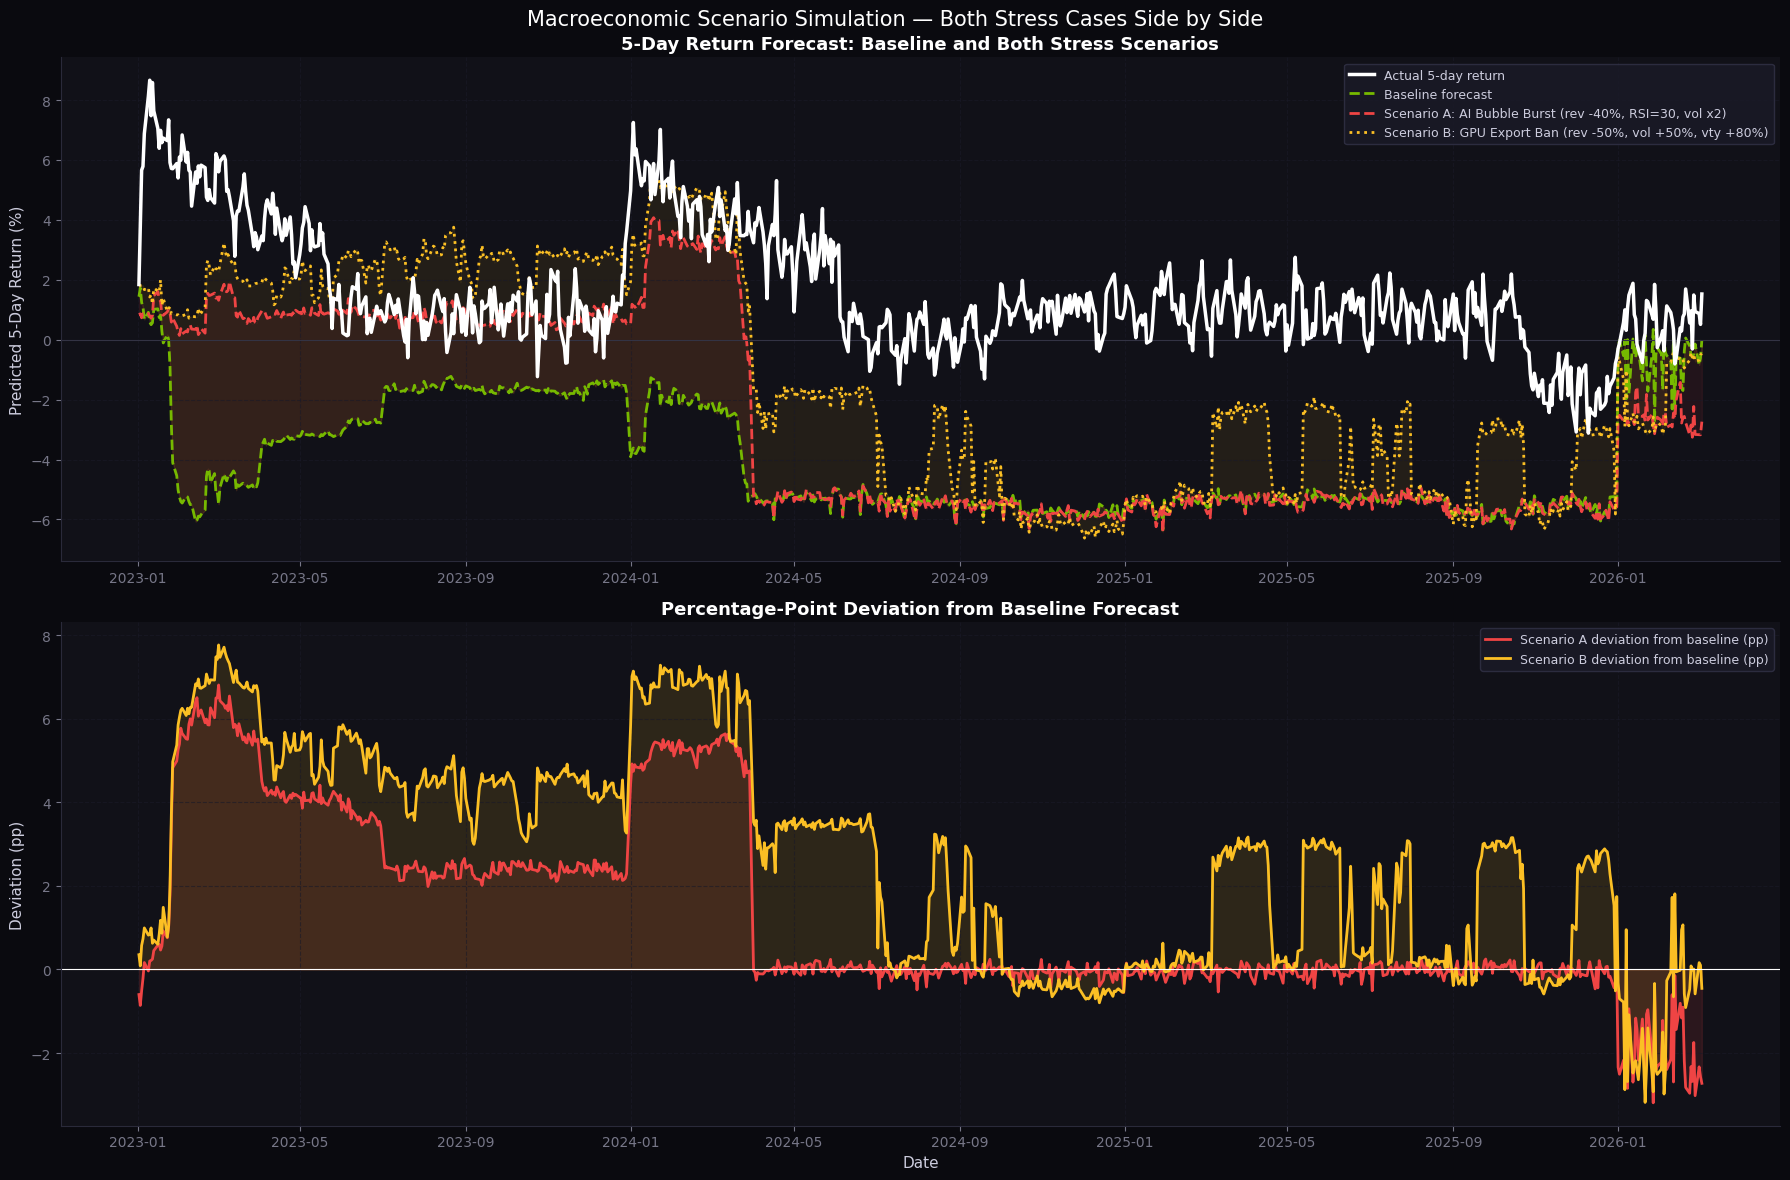

Scenario comparison over full test period:

  Baseline                Mean forecast: -4.035%  Dir acc: 17.9%
  AI Bubble Burst         Mean forecast: -2.729%  Dir acc: 51.2%
  GPU Export Ban          Mean forecast: -1.369%  Dir acc: 51.6%


In [22]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.suptitle('Macroeconomic Scenario Simulation — Both Stress Cases Side by Side',
             fontsize=15, color='white')

# Forecast trajectories
ax = axes[0]
ax.plot(test_df['date'], y_test*100,      color=NV_WHITE, linewidth=2.5,
        label='Actual 5-day return', zorder=5)
ax.plot(test_df['date'], base_preds*100,  color=NV_GREEN, linewidth=2,
        linestyle='--', label='Baseline forecast')
ax.plot(test_df['date'], preds_sc1*100,   color=RED,      linewidth=2,
        linestyle='--', label='Scenario A: AI Bubble Burst (rev -40%, RSI=30, vol x2)')
ax.plot(test_df['date'], preds_sc2*100,   color=GOLD,     linewidth=2,
        linestyle=':',  label='Scenario B: GPU Export Ban (rev -50%, vol +50%, vty +80%)')
ax.fill_between(test_df['date'], preds_sc1*100, base_preds*100, alpha=0.08, color=RED)
ax.fill_between(test_df['date'], preds_sc2*100, base_preds*100, alpha=0.08, color=GOLD)
ax.axhline(0, color='#333344', linewidth=0.8)
ax.set_title('5-Day Return Forecast: Baseline and Both Stress Scenarios')
ax.set_ylabel('Predicted 5-Day Return (%)')
ax.legend(fontsize=9)
ax.grid(True)

# Deviation from baseline
ax = axes[1]
dev_sc1 = (preds_sc1 - base_preds) * 100
dev_sc2 = (preds_sc2 - base_preds) * 100
ax.plot(test_df['date'], dev_sc1, color=RED,  linewidth=2,
        label='Scenario A deviation from baseline (pp)')
ax.plot(test_df['date'], dev_sc2, color=GOLD, linewidth=2,
        label='Scenario B deviation from baseline (pp)')
ax.fill_between(test_df['date'], dev_sc1, 0, alpha=0.12, color=RED)
ax.fill_between(test_df['date'], dev_sc2, 0, alpha=0.12, color=GOLD)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('Percentage-Point Deviation from Baseline Forecast')
ax.set_ylabel('Deviation (pp)')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('scenario_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("Scenario comparison over full test period:")
print()
for label, sc_preds in [('Baseline', base_preds), ('AI Bubble Burst', preds_sc1),
                         ('GPU Export Ban',  preds_sc2)]:
    dir_sc = np.mean(np.sign(y_test) == np.sign(sc_preds)) * 100
    print(f"  {label:<22}  Mean forecast: {sc_preds.mean()*100:+.3f}%  "
          f"Dir acc: {dir_sc:.1f}%")


## 12. Conclusions

This notebook built a complete financial forecasting pipeline across ten analytical stages using 27 years of NVIDIA stock data, with the 5-day forward return as the target variable.

The gradient boosting model beat the ARIMA baseline on MAE ($5.60% vs 3.56%) but both models struggled with direction accuracy on the test period, each landing near 17-18%. Understanding why this happened matters more than the number itself.

The 2023-2026 test period captured the generative AI rally, where NVIDIA's average 5-day return was 1.56%, roughly five times the 0.34% seen during training. Both models were trained on a distribution that looked nothing like the test period. The gradient boosting model learned that NVIDIA tends to drift modestly week to week. The test period produced sustained, large directional moves that fell outside what the training distribution implied. This is a regime change problem, not a model failure.

The feature importance analysis is the most instructive part of the notebook. When forecasting a 5-day return rather than a price level, rolling volatility becomes the most important feature at 34.7%, followed by lagged price levels and price standard deviation. Quarterly revenue contributes 11%, which is meaningful. RSI and volume contribute almost nothing. This distribution makes financial sense: short-term return magnitude is most predictable when you know how volatile the stock has been recently.

The scenario simulation showed that the GPU Export Ban scenario produced a larger forecast shift than the AI Bubble Burst, because the export ban scenario raises realised volatility, which the model weights heavily, while the bubble burst scenario lowers RSI, which the model barely uses.

Anomaly detection found 92 extreme 5-day return weeks across 7,079 trading days, roughly thirteen times more than a normal distribution would predict. Fat tails in individual equity returns are well-documented, but NVIDIA's numbers are extreme even by that standard. Any risk framework that assumes normally distributed returns will systematically underestimate the probability of large weekly moves.

Dataset: NVIDIA Stock Data 1999 to 2026. Target: 5-day forward return. Model: Gradient Boosting Regressor (200 trees, depth 4). Baseline: ARIMA(5,0,0). Evaluation: MAE, RMSE, direction accuracy on held-out 2023 to 2026 test period.
